# Cellpose-derived corridor processing, gray outside-hull display

This notebook reproduces the actual image source used for corridor-mask generation.

The **Cellpose flow TIFF** is the geometry input. The `FixedPattern` TIFF is optional and is retained only as the reference/background image used by the original registration workflow.

In the schematic, white is reserved for accessible corridor space. Pixels outside the convex hull are displayed in gray because they are excluded from analysis.


In [1]:
from pathlib import Path

SCRIPT_PATH = Path("corridor_processing_cellpose_exact_v2.py")

SURFACE = 1462

SETTINGS = {
    1462: {
        "cellpose_path": Path(r"..\cellpose flows 1462.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1462_binary_filled.tif"),
        "invert_cellpose": True,
        "rotation_deg": 28.34,
        "surface_name": "TopoChip feature 1462",
    },
    1476: {
        "cellpose_path": Path(r"..\cellpose flows 1476.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1476_binary_filled.tif"),
        "invert_cellpose": False,
        "rotation_deg": -13.47,
        "surface_name": "TopoChip feature 1476",
    },
}

cfg = SETTINGS[SURFACE]

CELLPOSE_IMAGE = cfg["cellpose_path"]
REFERENCE_IMAGE = cfg["reference_path"]  # optional; not used to generate the corridor mask
INVERT_CELLPOSE = cfg["invert_cellpose"]
ROTATION_DEG = cfg["rotation_deg"]
SURFACE_NAME = cfg["surface_name"]

PIXEL_SIZE_UM = 0.56
SCAN_STEP_PX = 1
ROW_COVERAGE_THRESHOLD = 0.07
MIN_ACCESSIBLE_COMPONENT_AREA = 16
MAX_FILLED_HOLE_AREA = 64
MERGE_GAP_PX = 3
MIN_BAND_HEIGHT = 5

SELECTED_CORRIDOR_ID = None
OUTPUT_DIR = Path(f"cellpose_corridor_processing_{SURFACE}")
SAVE_PDF = True

print("Geometry input:", CELLPOSE_IMAGE)
print("Reference only:", REFERENCE_IMAGE)
print("Invert Cellpose:", INVERT_CELLPOSE)
print("Rotation:", ROTATION_DEG)

Geometry input: ..\cellpose flows 1462.tif
Reference only: ..\FixedPattern_16x16_1462_binary_filled.tif
Invert Cellpose: True
Rotation: 28.34


## Load the processing file

In [2]:
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {SCRIPT_PATH.resolve()}\n"
        "Place the Python file beside this notebook or update SCRIPT_PATH."
    )

namespace = {"__name__": "corridor_processing_cellpose_exact"}
exec(
    compile(
        SCRIPT_PATH.read_text(encoding="utf-8"),
        str(SCRIPT_PATH.resolve()),
        "exec",
    ),
    namespace,
)

process_cellpose_corridors = namespace["process_cellpose_corridors"]
create_exact_processing_schematic = namespace["create_exact_processing_schematic"]

print("Functions loaded.")

Functions loaded.


## Validate the input paths

In [3]:
if not CELLPOSE_IMAGE.exists():
    raise FileNotFoundError(
        f"Cellpose input not found: {CELLPOSE_IMAGE.resolve()}"
    )

if not REFERENCE_IMAGE.exists():
    print(
        "Reference image was not found. This does not prevent corridor-mask "
        "processing, because the Cellpose image is the geometry source."
    )
    REFERENCE_IMAGE_FOR_RUN = None
else:
    REFERENCE_IMAGE_FOR_RUN = REFERENCE_IMAGE

print("Input paths checked.")

Input paths checked.


## Run the actual Cellpose-derived workflow

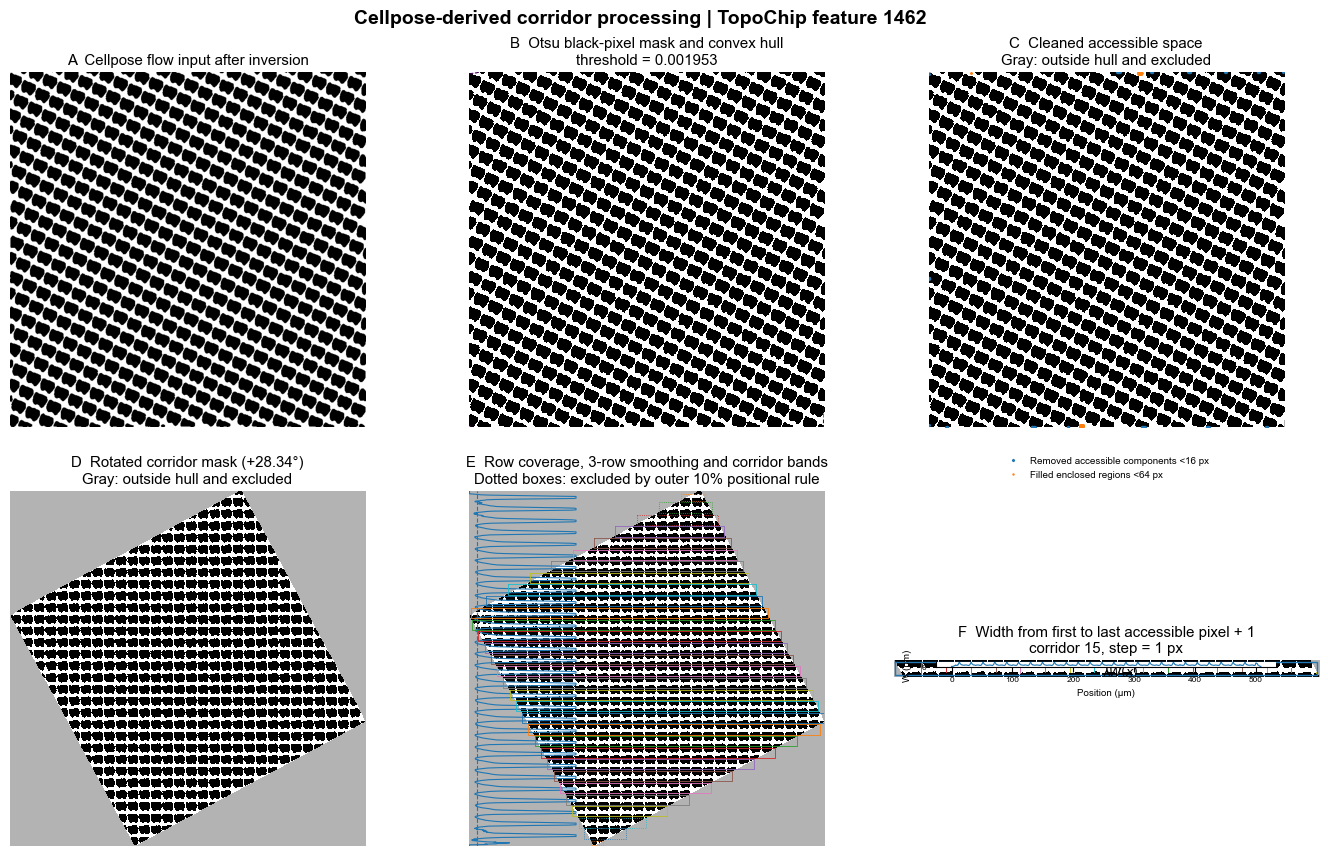

Detected bands: 31
Bands retained for width profiling after outer 10% rule: 25
Selected corridor: 15
Saved: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\cellpose_corridor_processing_1462\cellpose_corridor_processing_schematic.png


In [4]:
result = process_cellpose_corridors(
    cellpose_image=CELLPOSE_IMAGE,
    reference_image=REFERENCE_IMAGE_FOR_RUN,
    invert_cellpose=INVERT_CELLPOSE,
    rotation_deg=ROTATION_DEG,
    row_cov_thresh_rel_hull=ROW_COVERAGE_THRESHOLD,
    tiny_white_px=MIN_ACCESSIBLE_COMPONENT_AREA,
    hole_area_threshold=MAX_FILLED_HOLE_AREA,
    merge_gap_px=MERGE_GAP_PX,
    min_band_height=MIN_BAND_HEIGHT,
    scan_step_px=SCAN_STEP_PX,
    pixel_size_um=PIXEL_SIZE_UM,
)

create_exact_processing_schematic(
    result=result,
    surface_name=SURFACE_NAME,
    output_dir=OUTPUT_DIR,
    selected_corridor_id=SELECTED_CORRIDOR_ID,
    save_pdf=SAVE_PDF,
)

## Inspect detected corridor bands

In [ ]:
display(result["corridors"])

print(f"All detected bands: {len(result['corridors'])}")
print(
    "Retained after outer 10% positional filter:",
    int(result["corridors"]["used_for_width_profile"].sum()),
)
print(
    "Figure:",
    (OUTPUT_DIR / "cellpose_corridor_processing_schematic.png").resolve(),
)

## Display the saved schematic

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            OUTPUT_DIR / "cellpose_corridor_processing_schematic.png"
        )
    )
)